In [2]:
# ==========================================
# 1. IMPORT LIBRARIES AND LOAD DATASETS
# ==========================================

import glob
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Find all CSV files in the project directory
csv_files = glob.glob("daF*.csv")
csv_files.sort()

print("Available dataset files:")
datasets = {}
for i, file in enumerate(csv_files):
  try:
    # Try reading with semicolon separator and standard encoding
    datasets[file] = pd.read_csv(file, sep=";", encoding="utf-8")
  except UnicodeDecodeError:
    # Fallback to latin-1 if utf-8 fails due to special characters
    datasets[file] = pd.read_csv(file, sep=";", encoding="latin-1")

  print(
      f"{i+1}. {file} (Rows: {datasets[file].shape[0]}, Columns:"
      f" {datasets[file].shape[1]})"
  )

Available dataset files:
1. daF3496_eng.csv (Rows: 1169, Columns: 90)
2. daF3606_eng.csv (Rows: 1001, Columns: 96)
3. daF3676_eng.csv (Rows: 1002, Columns: 42)
4. daF3752_fin.csv (Rows: 1033, Columns: 109)
5. daF3856_fin.csv (Rows: 1197, Columns: 116)
6. daF3955_fin.csv (Rows: 1112, Columns: 116)
7. daF4066_fin.csv (Rows: 1072, Columns: 103)


In [3]:
# ==========================================
# 2. INSPECT COLUMNS OF A RECENT DATASET
# ==========================================

# Select one of the recent datasets, for example 'daF4066_fin.csv'
sample_file = "daF4066_fin.csv"
df_sample = datasets[sample_file]

# Print the first 30 column names to see what questions are available
print(f"First 30 columns in {sample_file}:")
print(list(df_sample.columns[:30]))

First 30 columns in daF4066_fin.csv:
['fsd_no', 'fsd_vr', 'fsd_id', 'MP1', 'MP_NATO', 'MP3', 'MP4', 'MP5', 'MP6', 'MP7a', 'MP7b', 'MP_PUOLUSTUSPOLITIIKKA', 'MP_TAHOT_1', 'MP_TAHOT_2', 'MP_TAHOT_3', 'MP_TAHOT_4', 'MP_TAHOT_5', 'MP_TAHOT_6', 'MP_TAHOT_7', 'MP_TAHOT_8', 'MP_TAHOT_9', 'MP_LAHIALUEET', 'MP_EU', 'MP_KYKY', 'MP_TURVALLISUUS_1', 'MP_TURVALLISUUS_2', 'MP_TURVALLISUUS_3', 'MP_TURVALLISUUS_4', 'MP_TURVALLISUUS_5', 'MP_HUOLTA_1']


In [4]:
# ==========================================
# 3. EXPLORE VALUES OF THE 'MP_NATO' COLUMN
# ==========================================

# Check value counts for MP_NATO in daF4066_fin.csv
nato_counts = datasets["daF4066_fin.csv"]["MP_NATO"].value_counts(dropna=False)
print("Value counts for MP_NATO in daF4066_fin.csv:")
print(nato_counts)

Value counts for MP_NATO in daF4066_fin.csv:
MP_NATO
4    476
3    398
5     79
2     71
1     48
Name: count, dtype: int64


C:\Users\koche\AppData\Local\Temp\ipykernel_83016\3778672619.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=nato_mapped, order=order, palette="Blues_d")


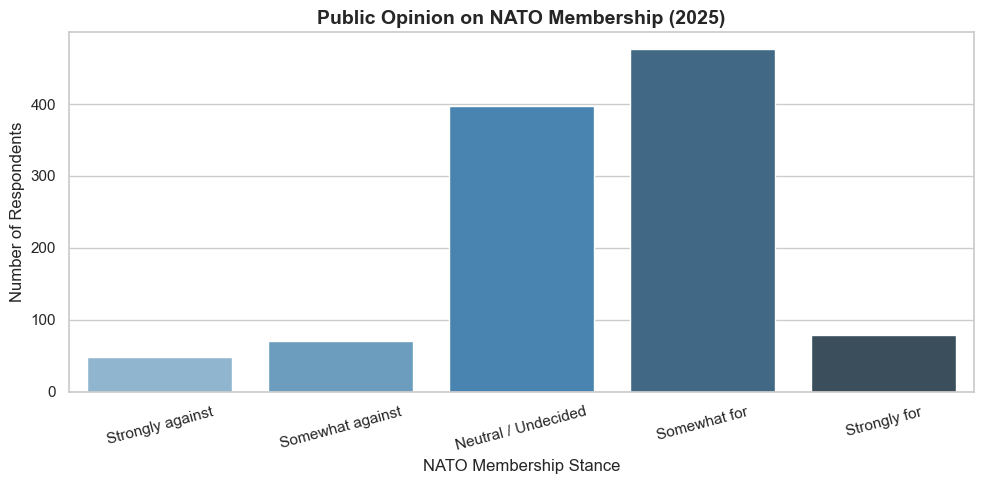

In [5]:
# ==========================================
# 4. PLOT THE DISTRIBUTION OF 'MP_NATO' (2025)
# ==========================================

import numpy as np

# Extract series and drop missing values
nato_series = datasets["daF4066_fin.csv"]["MP_NATO"].dropna()

# Map numeric codes to descriptive labels (based on FSD codebook for MP_NATO)
# Standard scale: 1 = Strongly against, 2 = Somewhat against, 3 = Neutral/Undecided, 4 = Somewhat for, 5 = Strongly for
label_mapping = {
    1.0: "Strongly against",
    2.0: "Somewhat against",
    3.0: "Neutral / Undecided",
    4.0: "Somewhat for",
    5.0: "Strongly for",
}

# Map values to labels for plotting
nato_mapped = nato_series.map(label_mapping)

# Create the count plot with sorted order
order = [
    "Strongly against",
    "Somewhat against",
    "Neutral / Undecided",
    "Somewhat for",
    "Strongly for",
]

plt.figure(figsize=(10, 5))
sns.countplot(x=nato_mapped, order=order, palette="Blues_d")

# Add titles and clean labels
plt.title(
    "Public Opinion on NATO Membership (2025)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("NATO Membership Stance", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=15)  # Rotate labels slightly for better readability

plt.tight_layout()
plt.show()

C:\Users\koche\AppData\Local\Temp\ipykernel_83016\892388991.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=nato_mapped_2021, order=order_q11, palette="Blues_d")


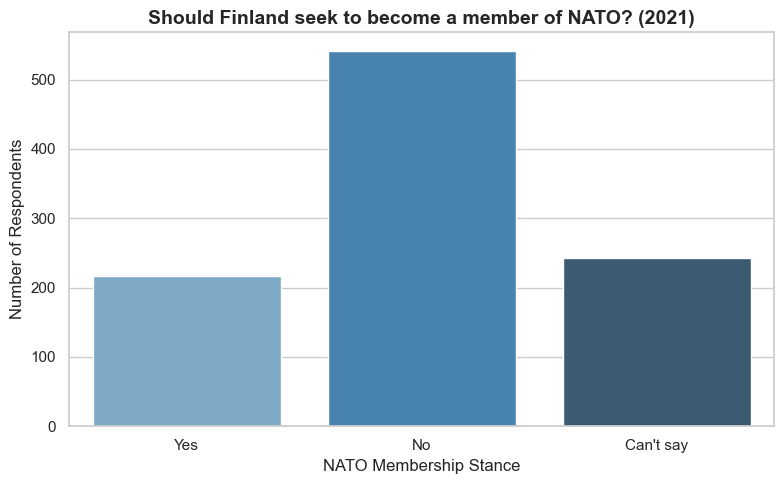

In [6]:
# ==========================================
# 5. PLOT THE DISTRIBUTION OF 'q11' (NATO Membership, 2021)
# ==========================================

# Ensure your datasets dictionary contains the file for 2021
file_key = "dad3606_fin.csv"  # or check the exact key name in your datasets dictionary

if file_key in datasets:
    df_2021 = datasets[file_key]
else:
    matching_keys = [k for k in datasets.keys() if "3606" in k]
    file_key = matching_keys[0] if matching_keys else list(datasets.keys())[0]
    df_2021 = datasets[file_key]

# Extract the series and drop missing values for q11 (NATO membership stance in 2021)
nato_series_2021 = df_2021["q11"].dropna()

# Map numeric codes to text labels based on the FSD codebook for q11
label_mapping_q11 = {
    1.0: "Yes",
    2.0: "No",
    3.0: "Can't say",
}

# Map the values for the plot
nato_mapped_2021 = nato_series_2021.map(label_mapping_q11)

# Set a fixed category order
order_q11 = [
    "Yes",
    "No",
    "Can't say",
]

plt.figure(figsize=(8, 5))
sns.countplot(x=nato_mapped_2021, order=order_q11, palette="Blues_d")

# Add titles and labels tailored for 2021 NATO Membership
plt.title(
    "Should Finland seek to become a member of NATO? (2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("NATO Membership Stance", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=0)  # No need to rotate since there are only 3 short categories

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# 6. CHECK DEMOGRAPHIC COLUMNS (GENDER & AGE) (2025)
# ==========================================

# Select the target dataframe (change the key if needed)
df = datasets["daF4066_fin.csv"]

# Get columns starting with 'bv' (background/demographic variables)
demo_cols = [col for col in df.columns if col.lower().startswith("bv")]
print("Available demographic columns:", demo_cols[:15])

# Print value counts for gender (bv1) and age (bv2)
for col in ["bv1", "bv2"]:
  if col in df.columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(5))

Available demographic columns: ['bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9_1', 'bv9_2', 'bv9_3', 'bv9_4', 'bv9_5', 'bv9_6', 'bv9_7']

Value counts for bv1:
bv1
1    549
2    520
3      3
Name: count, dtype: int64

Value counts for bv2:
bv2
64    30
32    28
16    26
49    24
37    24
Name: count, dtype: int64


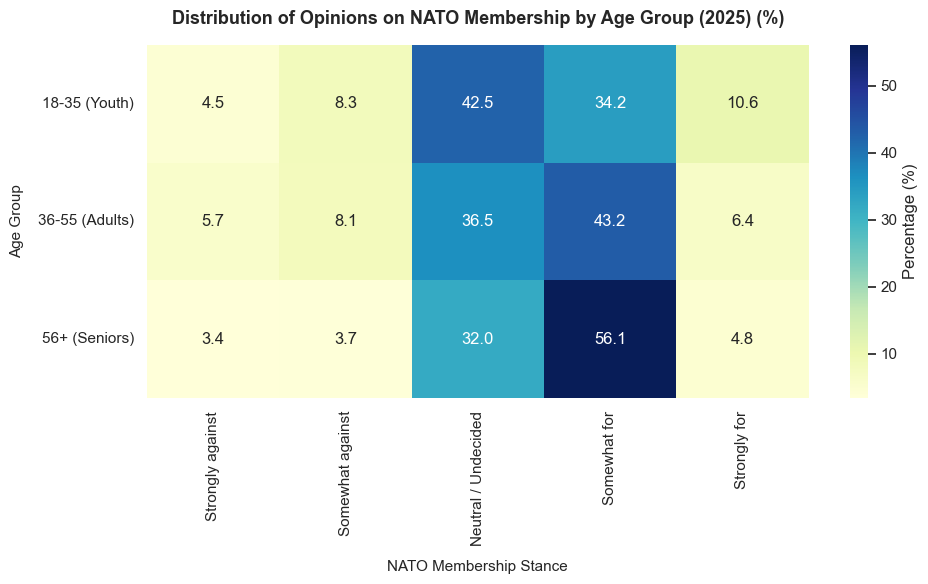

In [8]:
# ==========================================
# 7. HEATMAP: AGE GROUPS VS NATO OPINIONS
# ==========================================

# Create a copy and map data
df_analysis = df[["MP_NATO", "bv2"]].copy()

bins = [0, 35, 55, 120]
labels = ["18-35 (Youth)", "36-55 (Adults)", "56+ (Seniors)"]
df_analysis["Age_Group"] = pd.cut(
    df_analysis["bv2"], bins=bins, labels=labels, right=True
)

# Build cross-tabulation
crosstab_result = (
    pd.crosstab(
        df_analysis["Age_Group"], df_analysis["MP_NATO"], normalize="index"
    )
    * 100
)

# Rename columns to clear descriptive labels for opinions
nato_opinion_labels = {
    1: "Strongly against",
    2: "Somewhat against",
    3: "Neutral / Undecided",
    4: "Somewhat for",
    5: "Strongly for",
}
crosstab_result = crosstab_result.rename(columns=nato_opinion_labels)

# Plotting the clean heatmap (increased height to fix overlapping labels)
plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab_result,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    cbar_kws={"label": "Percentage (%)"},
)

plt.title(
    "Distribution of Opinions on NATO Membership by Age Group (2025) (%)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("NATO Membership Stance", fontsize=11, labelpad=10)
plt.ylabel("Age Group", fontsize=11, labelpad=10)

# Ensure y-axis labels are horizontal and well-spaced
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# 8. CHECK DEMOGRAPHIC COLUMNS (GENDER & AGE) (2021)
# ==========================================

# Select the target dataframe using the correct key
df = datasets["daF3606_eng.csv"]

# Get columns starting with 'bv' (background/demographic variables)
demo_cols = [col for col in df.columns if col.lower().startswith("bv")]
print("Available demographic columns:", demo_cols[:15])

# Print value counts for gender (bv1) and age (bv2)
for col in ["bv1", "bv2"]:
  if col in df.columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(5))

Available demographic columns: ['bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv9', 'bv10a', 'bv10b', 'bv11', 'bv12', 'bv13', 'bv14', 'bv15']

Value counts for bv1:
bv1
1    522
2    479
Name: count, dtype: int64

Value counts for bv2:
bv2
65    28
68    28
48    25
55    25
47    24
Name: count, dtype: int64


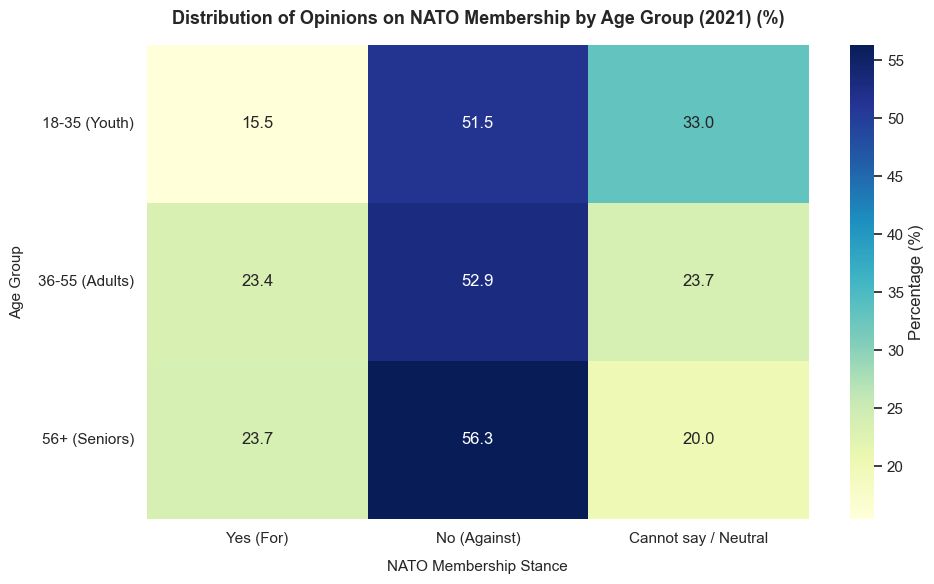

In [10]:
# ==========================================
#  9. HEATMAP: AGE GROUPS VS NATO OPINIONS (2021)
# ==========================================

# Select the target dataframe
df = datasets["daF3606_eng.csv"]

# Create a copy and map data for analysis (q11 for NATO opinion, bv2 for age)
df_analysis = df[["q11", "bv2"]].copy()

# Define age bins and labels
bins = [0, 35, 55, 120]
labels = ["18-35 (Youth)", "36-55 (Adults)", "56+ (Seniors)"]
df_analysis["Age_Group"] = pd.cut(
    df_analysis["bv2"], bins=bins, labels=labels, right=True
)

# Build cross-tabulation (normalizing by index to get percentages)
crosstab_result = (
    pd.crosstab(
        df_analysis["Age_Group"], df_analysis["q11"], normalize="index"
    )
    * 100
)

# Rename columns to clear descriptive labels for 2021 NATO stance opinions
# Note: In 2021 dataset (F3606), q11 typically has values: 1 = Yes, 2 = No, 3 = Cannot say / Don't know
nato_opinion_labels = {
    1: "Yes (For)",
    2: "No (Against)",
    3: "Cannot say / Neutral",
}
crosstab_result = crosstab_result.rename(columns=nato_opinion_labels)

# Plotting the clean heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab_result,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    cbar_kws={"label": "Percentage (%)"},
)

plt.title(
    "Distribution of Opinions on NATO Membership by Age Group (2021) (%)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("NATO Membership Stance", fontsize=11, labelpad=10)
plt.ylabel("Age Group", fontsize=11, labelpad=10)

# Ensure y-axis labels are horizontal and well-spaced
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

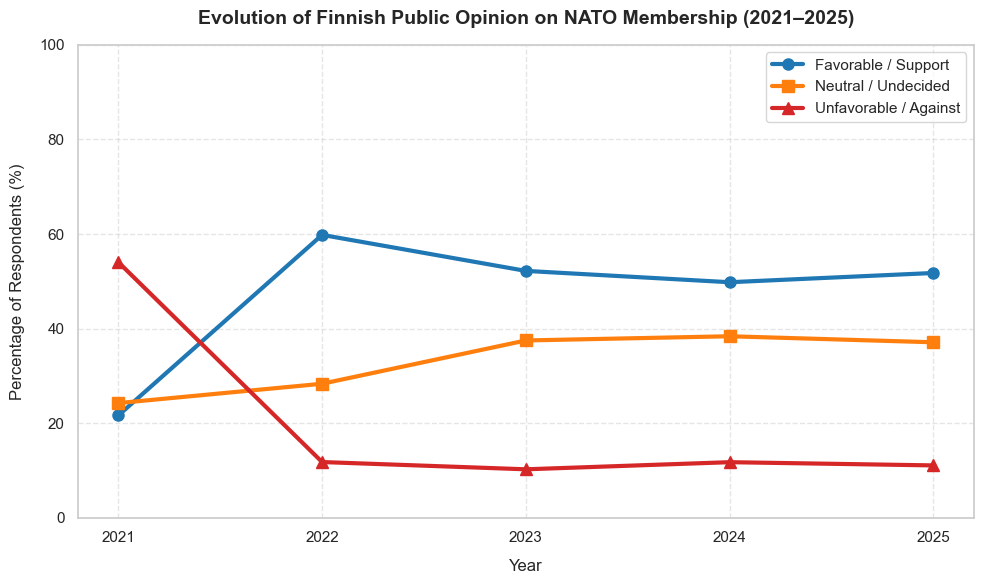

In [11]:
# ==========================================
# 10. FINAL TIME SERIES PLOT WITH YEAR LABELS
# ==========================================

wave_mapping = {
    "daF3606_eng.csv": {"year": "2021", "col": "q11", "fav": [1], "neu": [3], "unf": [2]},
    "daF3752_fin.csv": {"year": "2022", "col": "MP_NATO", "fav": [4, 5], "neu": [3], "unf": [1, 2]},
    "daF3856_fin.csv": {"year": "2023", "col": "MP_NATO", "fav": [4, 5], "neu": [3], "unf": [1, 2]},
    "daF3955_fin.csv": {"year": "2024", "col": "MP_NATO", "fav": [4, 5], "neu": [3], "unf": [1, 2]},
    "daF4066_fin.csv": {"year": "2025", "col": "MP_NATO", "fav": [4, 5], "neu": [3], "unf": [1, 2]},
}

trend_data = []

for file_key, info in wave_mapping.items():
    if file_key in datasets and info["col"] in datasets[file_key].columns:
        counts = datasets[file_key][info["col"]].value_counts(normalize=True) * 100
        
        trend_data.append({
            "Year": info["year"],
            "Favorable": sum(counts.get(k, 0) for k in info["fav"]),
            "Neutral": sum(counts.get(k, 0) for k in info["neu"]),
            "Unfavorable": sum(counts.get(k, 0) for k in info["unf"]),
        })

df_trend = pd.DataFrame(trend_data)

# Plotting the clean trend lines
plt.figure(figsize=(10, 6))

styles = [
    ("Favorable", "o", "#1f77b4", "Favorable / Support"),
    ("Neutral", "s", "#ff7f0e", "Neutral / Undecided"),
    ("Unfavorable", "^", "#d62728", "Unfavorable / Against")
]

for col, marker, color, label in styles:
    plt.plot(df_trend["Year"], df_trend[col], marker=marker, linewidth=3, markersize=8, label=label, color=color)

plt.title("Evolution of Finnish Public Opinion on NATO Membership (2021–2025)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Percentage of Respondents (%)", fontsize=12, labelpad=10)
plt.ylim(0, 100)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

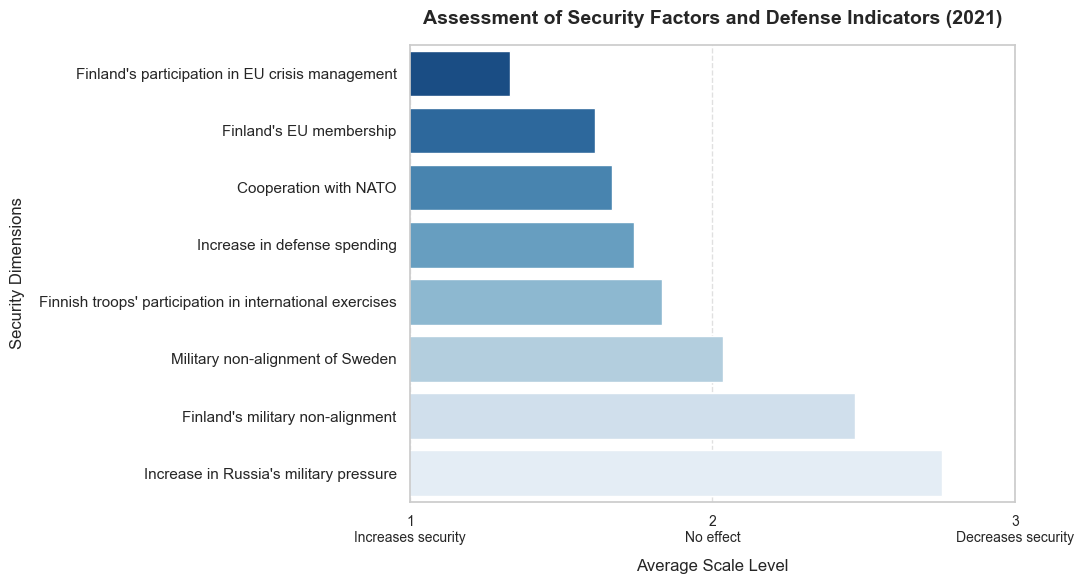

In [12]:
# ==========================================
# 11. SECURITY INDICATORS BAR CHART (2021)
# ==========================================

# Access the 2021 wave dataset
df_latest = datasets["daF3606_eng.csv"]

# Select security-related columns (e.g., q12 series on security factors)
security_cols = [col for col in df_latest.columns if col.startswith("q12_")]
security_means = df_latest[security_cols].mean().sort_values(ascending=True)

# Dictionary to map technical variable names to clean, readable labels for 2021
security_labels = {
    "q12_1": "Finland's EU membership",
    "q12_2": "Increase in defense spending",
    "q12_3": "Finland's military non-alignment",
    "q12_4": "Cooperation with NATO",
    "q12_5": "Finland's participation in EU crisis management",
    "q12_6": "Finnish troops' participation in international exercises",
    "q12_7": "Military non-alignment of Sweden",
    "q12_8": "Increase in Russia's military pressure",
}

# Apply mapping to the index, keeping original if not found in dict
security_means.index = security_means.index.map(
    lambda x: security_labels.get(x, x)
)

# Plotting the clean chart
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=security_means.values,
    y=security_means.index,
    hue=security_means.index,
    palette="Blues_r",
    legend=False,
)

# Set appropriate limits for the 2021 scale (e.g., 1 to 3 or 1 to 5 depending on coding)
plt.xlim(1, 3)

# Map numeric scale points to descriptive text labels for 2021 scale
plt.xticks(
    [1, 2, 3],
    [
        "1\nIncreases security",
        "2\nNo effect",
        "3\nDecreases security",
    ],
    fontsize=10,
)

plt.title(
    "Assessment of Security Factors and Defense Indicators (2021)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Average Scale Level", fontsize=12, labelpad=10)
plt.ylabel("Security Dimensions", fontsize=12, labelpad=10)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

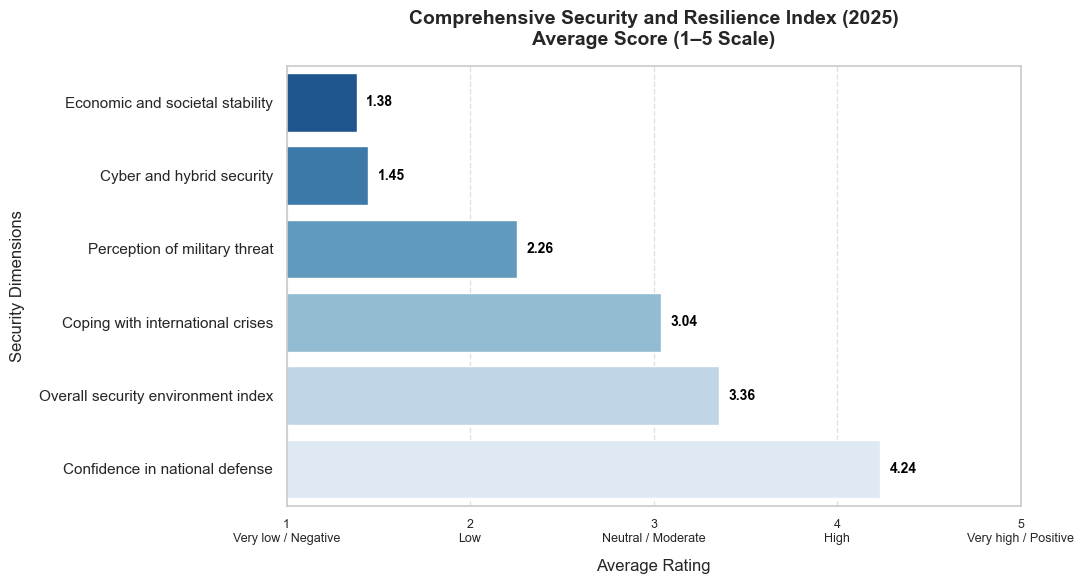

In [13]:
# ==========================================
# 12. SECURITY INDICATORS BAR CHART (2025)
# ==========================================

# 1. Load the dataset for 2025 and convert respondent weights
df = pd.read_csv("daF4066_fin.csv", sep=";")
df["weight"] = (
    pd.to_numeric(df["PAINO"].astype(str).str.replace(",", "."), errors="coerce")
    .fillna(1.0)
)

# 2. Define indicators mapping
indicators = {
    "Economic and societal stability": "MP_TURVALLISUUS_1",
    "Cyber and hybrid security": "MP_TURVALLISUUS_2",
    "Perception of military threat": "MP6",
    "Coping with international crises": "MP_KRIISINKESTVYYS",
    "Overall security environment index": "MP_PUOLUSTUSPOLITIIKKA",
    "Confidence in national defense": "MP_KYKY",
}

data_rows = []

# 3. Calculate direct weighted means (without confusing percentage normalization)
for label, col in indicators.items():
    if col in df.columns:
        s = pd.to_numeric(
            df[col].astype(str).str.replace(",", "."), errors="coerce"
        )
        valid_idx = s.dropna().index
        
        # Compute standard weighted mean
        raw_mean = (
            (s.loc[valid_idx] * df.loc[valid_idx, "weight"]).sum() 
            / df.loc[valid_idx, "weight"].sum()
        )

        data_rows.append(
            {
                "Dimension": label,
                "MeanScore": raw_mean,
            }
        )

# Create a DataFrame and sort values
plot_df = pd.DataFrame(data_rows).sort_values(by="MeanScore", ascending=True)

# 4. Plotting a clean, easy-to-read chart
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="MeanScore",
    y="Dimension",
    palette="Blues_r",
    hue="Dimension",
    legend=False,
)

# Set realistic scale bounds (assuming a standard 1-5 scale for these variables)
plt.xlim(1, 5)

# Clear X-axis ticks representing the survey scale
plt.xticks(
    [1, 2, 3, 4, 5],
    [
        "1\nVery low / Negative",
        "2\nLow",
        "3\nNeutral / Moderate",
        "4\nHigh",
        "5\nVery high / Positive",
    ],
    fontsize=9,
)

plt.title(
    "Comprehensive Security and Resilience Index (2025)\nAverage Score (1–5 Scale)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Average Rating", fontsize=12, labelpad=10)
plt.ylabel("Security Dimensions", fontsize=12, labelpad=10)
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Simple and clean numeric value labels directly on the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.2f}",
            (width + 0.05, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,
            color="black",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

<>:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
C:\Users\koche\AppData\Local\Temp\ipykernel_83016\784961273.py:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  plt.xlabel("Share of Respondents (\%)", fontsize=11)


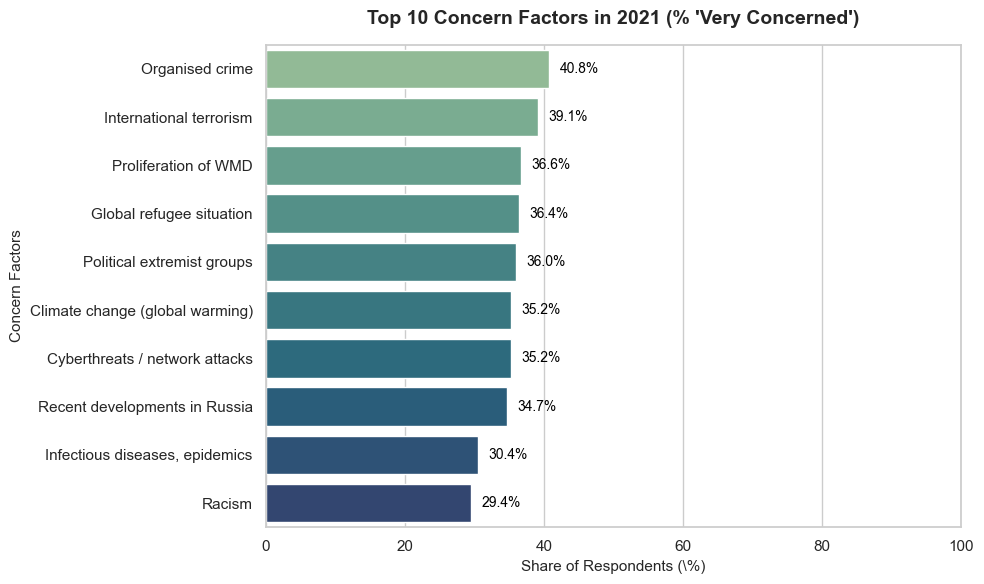

In [14]:
# ==========================================
# 13. TOP CONCERN FACTORS (PERCENTAGE OF "VERY CONCERNED") (2021)
# ==========================================

sns.set_theme(style="whitegrid")

# 1. Load data
df = pd.read_csv("daF3606_eng.csv", sep=";")

labels = {
    "q16_1": "Termination of arms control agreements",
    "q16_2": "Infectious diseases, epidemics",
    "q16_3": "Climate change (global warming)",
    "q16_4": "Security situation in Baltic Sea",
    "q16_5": "Proliferation of WMD",
    "q16_6": "Organised crime",
    "q16_7": "International terrorism",
    "q16_8": "Recent developments in the EU",
    "q16_9": "Recent developments in Belarus",
    "q16_10": "Recent developments in Russia",
    "q16_11": "Recent developments in the US",
    "q16_12": "Situation in Afghanistan",
    "q16_13": "Situation in the Middle East",
    "q16_14": "Situation in Ukraine",
    "q16_15": "Global refugee situation",
    "q16_16": "Political extremist groups",
    "q16_17": "Racism",
    "q16_18": "Fake news from foreign nations",
    "q16_19": "Cyberthreats / network attacks",
    "q16_20": "Employment situation in Finland",
    "q16_21": "Social inequality in Finland",
}

q16_cols = list(labels.keys())

# 2. Calculate percentage of respondents who chose code 4 ('Very concerned')
# Exclude code 5 ('Can't say') from the denominator (treat as NaN)
df_q16 = df[q16_cols].replace(5, pd.NA)

# For each column, find the share of values equal to 4
very_concerned_pct = (
    (df_q16 == 4).sum() / df_q16.notna().sum()
) * 100.0

# Map labels and select Top 10
top_10_pct = (
    very_concerned_pct.rename(index=labels)
    .sort_values(ascending=False)
    .head(10)
)

# 3. Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_10_pct.values,
    y=top_10_pct.index,
    palette="crest",
    hue=top_10_pct.index,
    legend=False,
)

plt.title(
    "Top 10 Concern Factors in 2021 (% 'Very Concerned')",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Share of Respondents (\%)", fontsize=11)
plt.ylabel("Concern Factors", fontsize=11)
plt.xlim(0, 100)

# Add values on bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 1.5, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,
            color="black",
        )

plt.tight_layout()
plt.show()

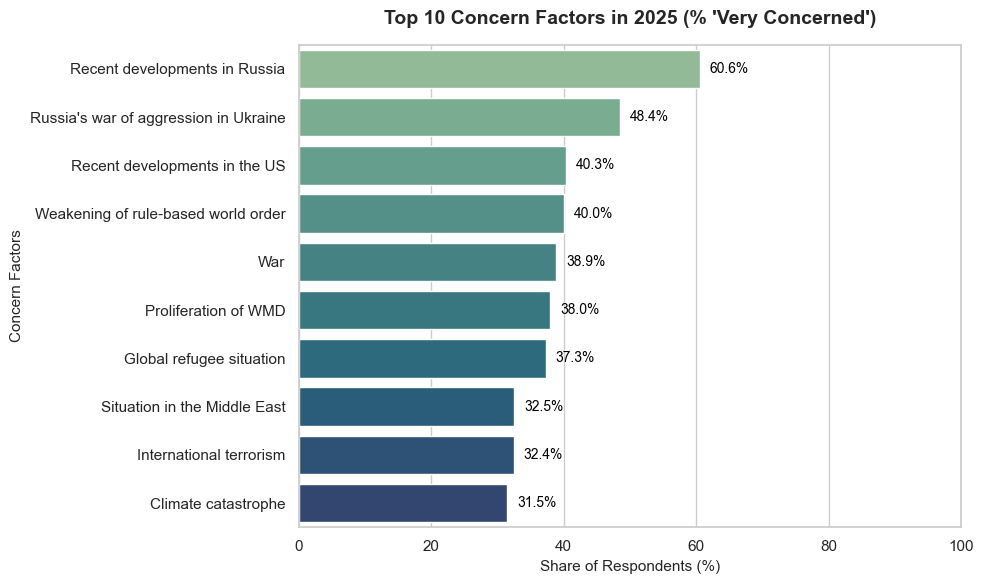

In [15]:
# ==========================================
# 14. TOP CONCERN FACTORS (2025) - % VERY CONCERNED
# ==========================================

# Set plot style
sns.set_theme(style="whitegrid")

# 1. Load data
df = pd.read_csv("daF4066_fin.csv", sep=";")

# 2. Dictionary with concise factor descriptions
labels = {
    "MP_HUOLTA_1": "Security situation in Arctic region",
    "MP_HUOLTA_2": "Recent developments in Russia",
    "MP_HUOLTA_3": "Recent developments in the US",
    "MP_HUOLTA_4": "Global refugee situation",
    "MP_HUOLTA_5": "Political pressure",
    "MP_HUOLTA_6": "Weakening of rule-based world order",
    "MP_HUOLTA_7": "International terrorism",
    "MP_HUOLTA_8": "Situation in the Middle East",
    "MP_HUOLTA_9": "Termination of arms control agreements",
    "MP_HUOLTA_10": "Security situation in Baltic Sea",
    "MP_HUOLTA_11": "Proliferation of WMD",
    "MP_HUOLTA_12": "War",
    "MP_HUOLTA_13": "Russia's war of aggression in Ukraine",
    "MP_HUOLTA_14": "Climate catastrophe",
    "MP_HUOLTA_15": "Major accidents",
    "MP_HUOLTA_16": "Infectious diseases and epidemics",
    "MP_HUOLTA_17": "Environmental threats",
    "MP_HUOLTA_18": "Digitalisation as tool of hostile influence",
    "MP_HUOLTA_19": "Availability of energy",
    "MP_HUOLTA_20": "Damage to critical infrastructure",
    "MP_HUOLTA_21": "Development of artificial intelligence",
    "MP_HUOLTA_22": "Cyberattacks / network attacks",
    "MP_HUOLTA_23": "Organised crime",
    "MP_HUOLTA_24": "Political extremist groups",
    "MP_HUOLTA_25": "Racism",
    "MP_HUOLTA_26": "Information influence directed at Finland",
    "MP_HUOLTA_27": "Social inequality in Finland",
    "MP_HUOLTA_28": "Societal polarization",
    "MP_HUOLTA_29": "Increase of non-EU/EEA ownership in Finnish economy",
    "MP_HUOLTA_30": "Inflation",
    "MP_HUOLTA_31": "Economic crisis (public finances)",
}

huolta_cols = list(labels.keys())

# 3. Replace code 5 ('Can't say') with NaN, compute % of code 4 ('Very concerned'), and get Top 10
df_huolta = df[huolta_cols].replace(5, pd.NA)
very_concerned_pct = (
    (df_huolta == 4).sum() / df_huolta.notna().sum()
) * 100.0

top_10_pct = (
    very_concerned_pct.rename(index=labels)
    .sort_values(ascending=False)
    .head(10)
)

# 4. Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_10_pct.values,
    y=top_10_pct.index,
    palette="crest",
    hue=top_10_pct.index,
    legend=False,
)

plt.title(
    "Top 10 Concern Factors in 2025 (% 'Very Concerned')",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Share of Respondents (%)", fontsize=11)
plt.ylabel("Concern Factors", fontsize=11)
plt.xlim(0, 100)

# Add values on bars for clarity
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 1.5, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,
            color="black",
        )

plt.tight_layout()
plt.show()